# TP2 - Etapa 1: Búsqueda por Similitud con Embeddings

Notebook de la Etapa 1: construcción de la base vectorial, búsqueda por similitud
y evaluación con Accuracy y NDCG@10.

Se evalúan tres modelos de embedding:
- **Baseline**: ResNet18 preentrenado en ImageNet (sin fine-tuning)
- **ResNet18 fine-tuned**: ResNet18 ajustado en el dataset de 70 razas
- **CNN custom**: CNN propia entrenada desde cero

Los resultados fueron generados localmente con GPU RTX 3060.

## Equipo
- Alumno 1: Lautaro Florenza
- Alumno 2: Sebastian Palacio

## 1. Descripción del sistema

El buscador de imágenes por similitud funciona de la siguiente manera:

1. Se extrae un embedding de la imagen de consulta usando el modelo seleccionado.
2. Se calcula la similitud coseno entre ese embedding y todos los almacenados en el índice.
3. Se recuperan los top-K vecinos más similares.
4. La raza predicha se determina por voto mayoritario entre los K vecinos.

El índice se construye con `scripts/build_index.py` y se almacena en `data/embeddings.json`
(modo demo) o en PostgreSQL + pgvector (modo completo con `USE_PGVECTOR=true`).

## 2. Setup

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

ROOT = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path("/content/proyecto")
OUTPUT = ROOT / "output"

print("ROOT:", ROOT)
print("OUTPUT existe:", OUTPUT.exists())

ROOT: c:\Users\Sebas\TP2_VC
OUTPUT existe: True


## 3. Cargar resultados de evaluación

Los resultados se generaron con:
```powershell
python scripts/evaluate_similarity.py --model baseline --split valid --limit-per-class 3 --top-k 10
python scripts/evaluate_similarity.py --model resnet18_finetuned --split valid --limit-per-class 3 --top-k 10
python scripts/evaluate_similarity.py --model cnn_custom --split valid --limit-per-class 3 --top-k 10
```

In [9]:
with open(OUTPUT / "baseline_similarity_metrics.json") as f:
    baseline = json.load(f)
with open(OUTPUT / "resnet18_finetuned_similarity_metrics.json") as f:
    resnet = json.load(f)
with open(OUTPUT / "cnn_custom_similarity_metrics.json") as f:
    cnn = json.load(f)

print("Configuracion de evaluacion:")
print(f"  Split: {baseline['split']}")
print(f"  Imagenes por raza: {baseline['limit_per_class']}")
print(f"  Top-K: {baseline['top_k']}")
print(f"  Total consultas: {baseline['queries']}")

print("\nResultados globales:")
print(f"  {'Modelo':<25} {'Accuracy':>10} {'NDCG@10':>10} {'Correctas':>10}")
print("  " + "-" * 60)
for name, data in [("Baseline", baseline), ("ResNet18 fine-tuned", resnet), ("CNN custom", cnn)]:
    print(f"  {name:<25} {data['accuracy']:>10.4f} {data['ndcg_at_k']:>10.4f} {data['correct']:>10}/{data['queries']}")

Configuracion de evaluacion:
  Split: valid
  Imagenes por raza: 3
  Top-K: 10
  Total consultas: 210

Resultados globales:
  Modelo                      Accuracy    NDCG@10  Correctas
  ------------------------------------------------------------
  Baseline                      0.9429     0.9460        198/210
  ResNet18 fine-tuned           0.9476     0.9429        199/210
  CNN custom                    0.5190     0.6572        109/210


## 4. Comparación visual de métricas

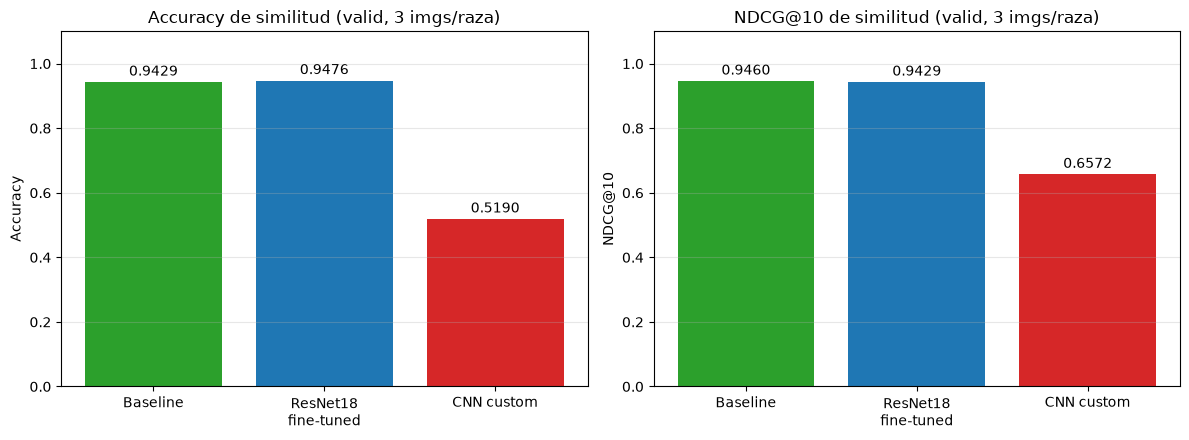

In [10]:
models = ["Baseline", "ResNet18\nfine-tuned", "CNN custom"]
accuracies = [baseline["accuracy"], resnet["accuracy"], cnn["accuracy"]]
ndcgs = [baseline["ndcg_at_k"], resnet["ndcg_at_k"], cnn["ndcg_at_k"]]
colors = ["#2ca02c", "#1f77b4", "#d62728"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars = axes[0].bar(models, accuracies, color=colors)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy de similitud (valid, 3 imgs/raza)")
axes[0].grid(axis="y", alpha=0.3)
for bar, v in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.4f}", ha="center", fontsize=10)
    
bars = axes[1].bar(models, ndcgs, color=colors)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("NDCG@10")
axes[1].set_title("NDCG@10 de similitud (valid, 3 imgs/raza)")
axes[1].grid(axis="y", alpha=0.3)
for bar, v in zip(bars, ndcgs):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.4f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## 5. Accuracy por raza — análisis de clases difíciles

In [11]:
for name, data in [("Baseline", baseline), ("ResNet18 fine-tuned", resnet), ("CNN custom", cnn)]:
    per_class = data["per_class_accuracy"]
    worst = sorted(per_class.items(), key=lambda x: x[1])[:10]
    print(f"\n{name} — 10 razas con peor accuracy:")
    print(f"  {'Raza':<25} {'Accuracy':>10}")
    print("  " + "-" * 38)
    for breed, acc in worst:
        print(f"  {breed:<25} {acc:>10.4f}")


Baseline — 10 razas con peor accuracy:
  Raza                        Accuracy
  --------------------------------------
  American  Spaniel             0.0000
  Boston Terrier                0.3333
  Lhasa                         0.3333
  Chinese Crested               0.6667
  Great Dane                    0.6667
  Malinois                      0.6667
  Shar_Pei                      0.6667
  Shiba Inu                     0.6667
  Afghan                        1.0000
  African Wild Dog              1.0000

ResNet18 fine-tuned — 10 razas con peor accuracy:
  Raza                        Accuracy
  --------------------------------------
  American  Spaniel             0.0000
  Lhasa                         0.3333
  Airedale                      0.6667
  Boston Terrier                0.6667
  Cairn                         0.6667
  Elk Hound                     0.6667
  Great Dane                    0.6667
  Siberian Husky                0.6667
  Afghan                        1.0000
  Africa

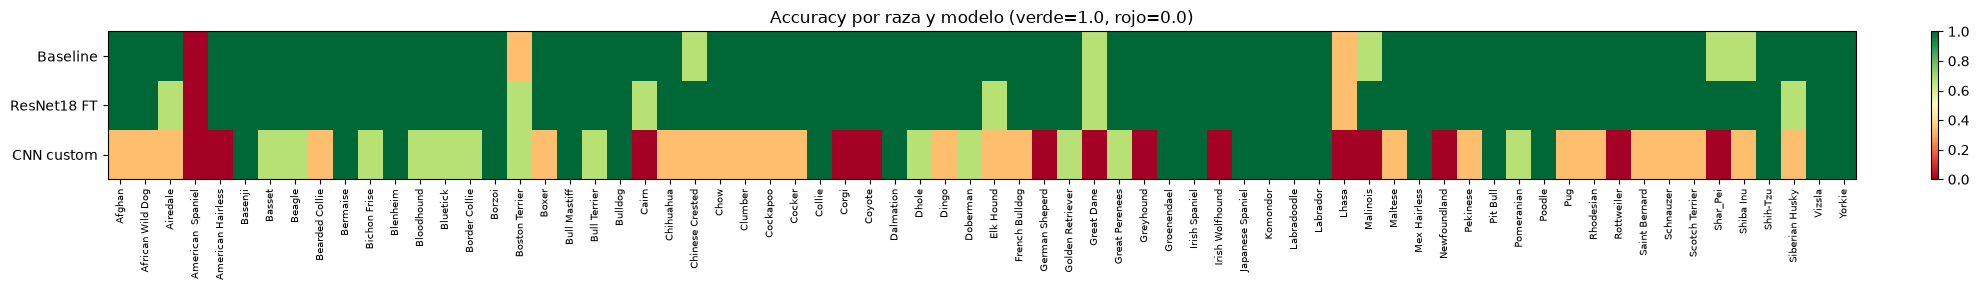

In [12]:
# Heatmap de accuracy por raza para los tres modelos
breeds = sorted(baseline["per_class_accuracy"].keys())
baseline_acc = [baseline["per_class_accuracy"].get(b, 0) for b in breeds]
resnet_acc   = [resnet["per_class_accuracy"].get(b, 0) for b in breeds]
cnn_acc      = [cnn["per_class_accuracy"].get(b, 0) for b in breeds]

matrix = np.array([baseline_acc, resnet_acc, cnn_acc])

fig, ax = plt.subplots(figsize=(20, 3))
im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Baseline", "ResNet18 FT", "CNN custom"])
ax.set_xticks(range(len(breeds)))
ax.set_xticklabels(breeds, rotation=90, fontsize=7)
ax.set_title("Accuracy por raza y modelo (verde=1.0, rojo=0.0)")
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.04)
plt.tight_layout()
plt.show()

## 6. Análisis de NDCG por consulta

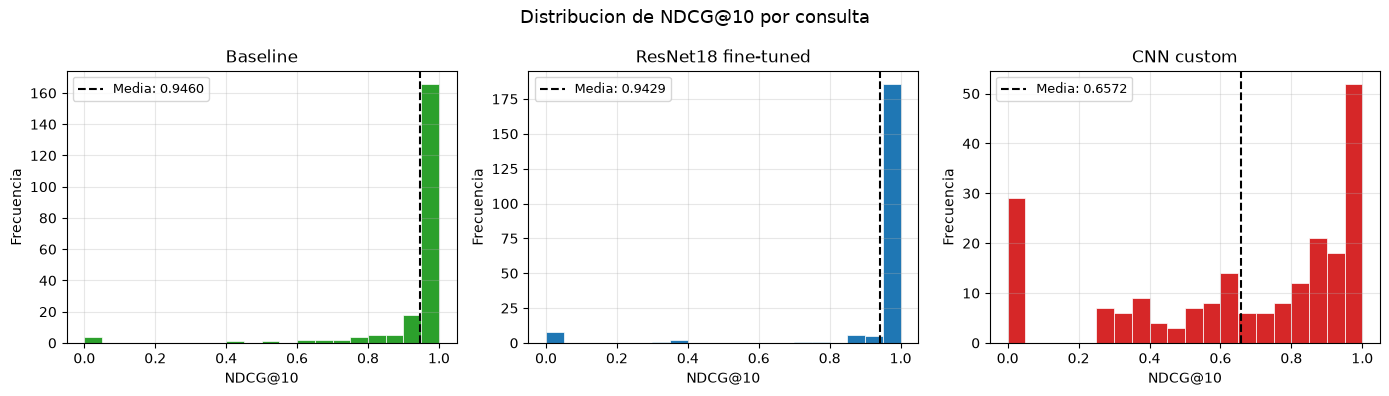

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, data), color in zip(
    axes,
    [("Baseline", baseline), ("ResNet18 fine-tuned", resnet), ("CNN custom", cnn)],
    ["#2ca02c", "#1f77b4", "#d62728"]
):
    ndcg_scores = [p["ndcg"] for p in data["predictions"]]
    ax.hist(ndcg_scores, bins=20, color=color, edgecolor="white", linewidth=0.5)
    ax.axvline(x=data["ndcg_at_k"], color="black", linestyle="--", linewidth=1.5,
               label=f"Media: {data['ndcg_at_k']:.4f}")
    ax.set_title(name)
    ax.set_xlabel("NDCG@10")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Distribucion de NDCG@10 por consulta", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Ejemplo de búsqueda exitosa y fallida

In [14]:
predictions = baseline["predictions"]
correct_ex   = next(p for p in predictions if p["correct"])
incorrect_ex = next((p for p in predictions if not p["correct"]), None)

print("Ejemplo de busqueda CORRECTA (baseline):")
print(f"  Imagen:     {Path(correct_ex['path']).name}")
print(f"  Raza real:  {correct_ex['true_breed']}")
print(f"  Prediccion: {correct_ex['predicted_breed']}")
print(f"  Score:      {correct_ex['score']:.4f}")
print(f"  NDCG:       {correct_ex['ndcg']:.4f}")

if incorrect_ex:
    print("\nEjemplo de busqueda INCORRECTA (baseline):")
    print(f"  Imagen:     {Path(incorrect_ex['path']).name}")
    print(f"  Raza real:  {incorrect_ex['true_breed']}")
    print(f"  Prediccion: {incorrect_ex['predicted_breed']}")
    print(f"  Score:      {incorrect_ex['score']:.4f}")
    print(f"  NDCG:       {incorrect_ex['ndcg']:.4f}")
else:
    print("\nNo hay ejemplos incorrectos en baseline para este subset.")

Ejemplo de busqueda CORRECTA (baseline):
  Imagen:     01.jpg
  Raza real:  Afghan
  Prediccion: Afghan
  Score:      0.8836
  NDCG:       0.9668

Ejemplo de busqueda INCORRECTA (baseline):
  Imagen:     01.jpg
  Raza real:  American  Spaniel
  Prediccion: Irish Spaniel
  Score:      0.8731
  NDCG:       0.0000


## 8. Tabla resumen final

| Modelo de embedding | Accuracy | NDCG@10 | Consultas correctas |
| --- | ---: | ---: | ---: |
| Baseline | 0.9429 | 0.9460 | 198/210 |
| ResNet18 fine-tuned | 0.9476 | 0.9429 | 199/210 |
| CNN custom | 0.5190 | 0.6572 | 109/210 |

## 9. Análisis y conclusiones

El **Baseline** y **ResNet18 fine-tuned** obtienen resultados muy similares en ambas métricas.
Esto indica que ResNet18 preentrenado en ImageNet ya genera embeddings de alta calidad para
discriminar razas de perros, y el fine-tuning aporta una mejora marginal en accuracy (+0.005)
pero un NDCG@10 ligeramente menor, lo que sugiere que el fine-tuning reorganiza el espacio
de embeddings priorizando la predicción correcta en primera posición.

La **CNN custom** queda significativamente por debajo (0.519 accuracy, 0.657 NDCG@10),
lo que es consistente con sus métricas de clasificación (0.50 accuracy en test). Sin embargo,
el NDCG@10 de 0.657 indica que los embeddings capturan información útil: cuando falla la
predicción por voto mayoritario, la imagen correcta suele aparecer en posiciones altas del ranking.

Los errores se concentran en razas morfológicamente similares (distintos tipos de Spaniel,
razas de pelo largo), lo que es esperable en un problema de fine-grained recognition.